# Problem 1a

<>:131: SyntaxWarning: invalid escape sequence '\g'
<>:131: SyntaxWarning: invalid escape sequence '\g'
/var/folders/3t/37pxq25x67z4s0vkj0dlgbsm0000gn/T/ipykernel_12437/10043257.py:131: SyntaxWarning: invalid escape sequence '\g'
  labels = ['C1 ($X_1 \geq 150$)', 'C2 ($X_2 < 10$)', 'C3 ($X_3 > 100$)']


Simulating probabilities...

Results after 10000 simulations:
Pr(C1: X1 >= 150) = 0.0000
Pr(C2: X2 < 10)   = 0.0000
Pr(C3: X3 > 100)  = 1.0000

Saved probability plot to 'hitting_probabilities.png'
Simulating and plotting trajectories...
Saved trajectory plot to 'molecule_trajectories.png'


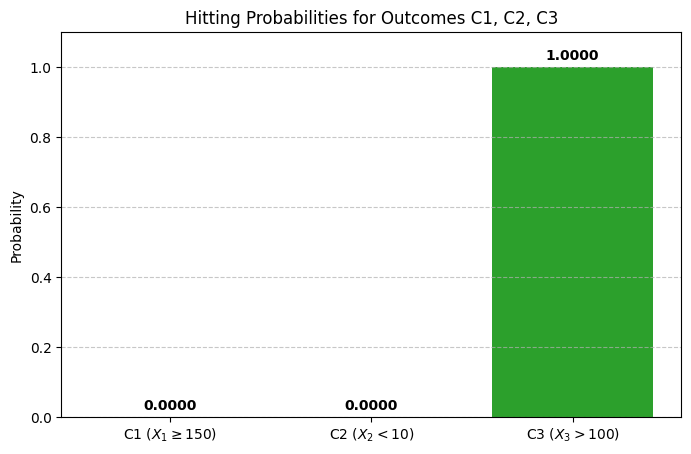

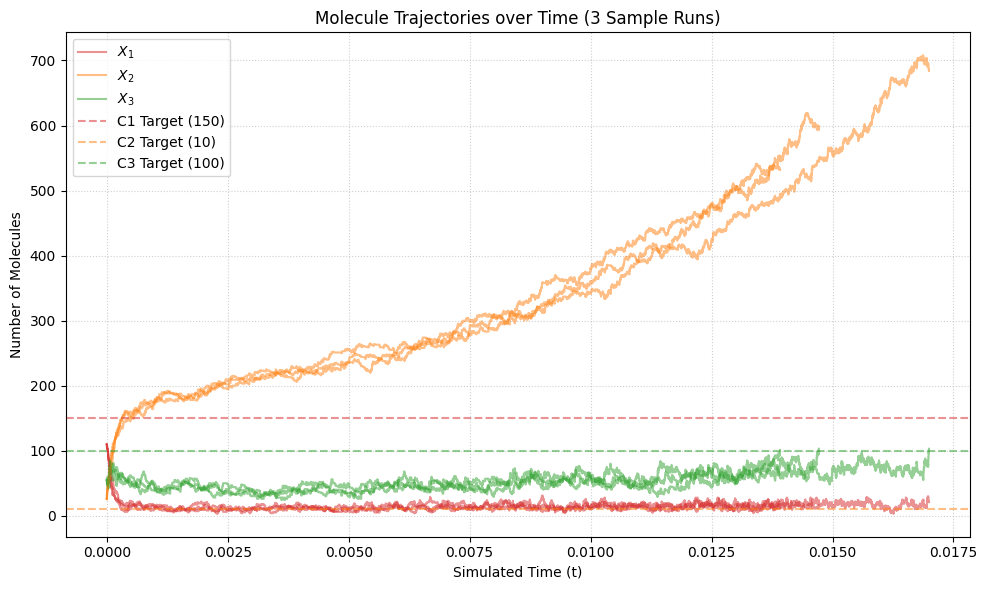

In [9]:
import numpy as np
import matplotlib.pyplot as plt
seed = np.random.seed(14)

def simulate_hitting_probabilities(trials=10000):
    c1_count = 0
    c2_count = 0
    c3_count = 0
    
    for _ in range(trials):
        x1, x2, x3 = 110, 26, 55
        
        while True:
            # Check stopping conditions
            if x1 >= 150:
                c1_count += 1
                break
            if x2 < 10:
                c2_count += 1
                break
            if x3 > 100:
                c3_count += 1
                break
                
            # Calculate propensities
            a1 = 1.0 * (x1 * (x1 - 1) / 2.0) * x2 if x1 >= 2 and x2 >= 1 else 0
            a2 = 2.0 * x1 * (x3 * (x3 - 1) / 2.0) if x1 >= 1 and x3 >= 2 else 0
            a3 = 3.0 * x2 * x3 if x2 >= 1 and x3 >= 1 else 0
            
            a0 = a1 + a2 + a3
            if a0 == 0:
                break # System deadlock
                
            p1 = a1 / a0
            p2 = a2 / a0
            
            # Roll the weighted dice
            r = np.random.rand()
            if r < p1:
                x1, x2, x3 = x1 - 2, x2 - 1, x3 + 4
            elif r < p1 + p2:
                x1, x2, x3 = x1 - 1, x2 + 3, x3 - 2
            else:
                x1, x2, x3 = x1 + 2, x2 - 1, x3 - 1
                
    return c1_count, c2_count, c3_count

def plot_sample_trajectories(num_samples=3):
    """Runs a few simulations and records the history to plot the trajectories."""
    plt.figure(figsize=(10, 6))
    
    colors = ['#d62728', '#ff7f0e', '#2ca02c'] # Red, Orange, Green
    
    for i in range(num_samples):
        x1, x2, x3 = 110, 26, 55
        t = 0.0
        
        t_hist = [t]
        x1_hist = [x1]
        x2_hist = [x2]
        x3_hist = [x3]
        
        while True:
            if x1 >= 150 or x2 < 10 or x3 > 100:
                break
                
            a1 = 1.0 * (x1 * (x1 - 1) / 2.0) * x2 if x1 >= 2 and x2 >= 1 else 0
            a2 = 2.0 * x1 * (x3 * (x3 - 1) / 2.0) if x1 >= 1 and x3 >= 2 else 0
            a3 = 3.0 * x2 * x3 if x2 >= 1 and x3 >= 1 else 0
            
            a0 = a1 + a2 + a3
            if a0 == 0:
                break
                
            # Advance stochastic time
            dt = -np.log(np.random.rand()) / a0
            t += dt
            
            p1 = a1 / a0
            p2 = a2 / a0
            
            r = np.random.rand()
            if r < p1:
                x1, x2, x3 = x1 - 2, x2 - 1, x3 + 4
            elif r < p1 + p2:
                x1, x2, x3 = x1 - 1, x2 + 3, x3 - 2
            else:
                x1, x2, x3 = x1 + 2, x2 - 1, x3 - 1
                
            t_hist.append(t)
            x1_hist.append(x1)
            x2_hist.append(x2)
            x3_hist.append(x3)
            
        # Plotting step functions for the stochastic jumps
        alpha_val = 0.8 if num_samples == 1 else 0.5
        plt.step(t_hist, x1_hist, where='post', color=colors[0], alpha=alpha_val, label='$X_1$' if i==0 else "")
        plt.step(t_hist, x2_hist, where='post', color=colors[1], alpha=alpha_val, label='$X_2$' if i==0 else "")
        plt.step(t_hist, x3_hist, where='post', color=colors[2], alpha=alpha_val, label='$X_3$' if i==0 else "")

    # Draw stopping condition lines
    plt.axhline(y=150, color='#d62728', linestyle='--', alpha=0.5, label='C1 Target (150)')
    plt.axhline(y=10, color='#ff7f0e', linestyle='--', alpha=0.5, label='C2 Target (10)')
    plt.axhline(y=100, color='#2ca02c', linestyle='--', alpha=0.5, label='C3 Target (100)')

    plt.title(f'Molecule Trajectories over Time ({num_samples} Sample Runs)')
    plt.xlabel('Simulated Time (t)')
    plt.ylabel('Number of Molecules')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig('molecule_trajectories.png')
    print("Saved trajectory plot to 'molecule_trajectories.png'")

if __name__ == '__main__':
    # 1. Run the probabilities
    trials = 10000
    print("Simulating probabilities...")
    c1, c2, c3 = simulate_hitting_probabilities(trials)
    
    p1 = c1 / trials
    p2 = c2 / trials
    p3 = c3 / trials
    
    print(f"\nResults after {trials} simulations:")
    print(f"Pr(C1: X1 >= 150) = {p1:.4f}")
    print(f"Pr(C2: X2 < 10)   = {p2:.4f}")
    print(f"Pr(C3: X3 > 100)  = {p3:.4f}\n")

    # 2. Plot probabilities
    labels = ['C1 ($X_1 \geq 150$)', 'C2 ($X_2 < 10$)', 'C3 ($X_3 > 100$)']
    probs = [p1, p2, p3]
    
    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, probs, color=['#d62728', '#ff7f0e', '#2ca02c'])
    plt.ylabel('Probability')
    plt.title('Hitting Probabilities for Outcomes C1, C2, C3')
    plt.ylim(0, 1.1)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.4f}", ha='center', fontweight='bold')
        
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig('hitting_probabilities.png')
    print("Saved probability plot to 'hitting_probabilities.png'")
    
    # 3. Plot the trajectories
    print("Simulating and plotting trajectories...")
    plot_sample_trajectories(num_samples=3)

# Problem 1b

In [10]:
import numpy as np
seed = np.random.seed(14)
def simulate_reaction_network(trials=100000, steps=7):
    initial_state = np.array([9, 8, 7])
    
    # Stoichiometry matrix: how each reaction changes [X1, X2, X3]
    updates = np.array([
        [-2, -1,  4],  # R1
        [-1,  3, -2],  # R2
        [ 2, -1, -1]   # R3
    ])
    
    # Array to store the final state of each trial
    final_states = np.zeros((trials, 3))
    
    for i in range(trials):
        state = initial_state.copy()
        
        for _ in range(steps):
            x1, x2, x3 = state
            
            # Calculate propensities (with safety checks for negative molecule counts)
            a1 = 1.0 * (x1 * (x1 - 1) / 2.0) * x2 if x1 >= 2 and x2 >= 1 else 0
            a2 = 2.0 * x1 * (x3 * (x3 - 1) / 2.0) if x1 >= 1 and x3 >= 2 else 0
            a3 = 3.0 * x2 * x3 if x2 >= 1 and x3 >= 1 else 0
            
            a0 = a1 + a2 + a3
            if a0 == 0:
                break # System deadlocked
                
            # Probabilities
            p1 = a1 / a0
            p2 = a2 / a0
            
            # Select and execute reaction
            r = np.random.rand()
            if r < p1:
                state += updates[0]
            elif r < p1 + p2:
                state += updates[1]
            else:
                state += updates[2]
                
        final_states[i] = state
        
    # Calculate Mean and Variance
    means = np.mean(final_states, axis=0)
    variances = np.var(final_states, axis=0)
    
    print(f"Results after {trials} trials:")
    print(f"X1 -> Mean: {means[0]:.3f}, Variance: {variances[0]:.3f}")
    print(f"X2 -> Mean: {means[1]:.3f}, Variance: {variances[1]:.3f}")
    print(f"X3 -> Mean: {means[2]:.3f}, Variance: {variances[2]:.3f}")

if __name__ == '__main__':
    simulate_reaction_network()

Results after 100000 trials:
X1 -> Mean: 5.837, Variance: 5.880
X2 -> Mean: 12.485, Variance: 8.939
X3 -> Mean: 7.815, Variance: 8.961
